In [61]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

# statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

## Introduction

### Benchmarks:
- Moving AVG.
- Momentum
- AR(1) (univariate models) (ARMA)
- PCA (k-factor model) -> maybe VAR on the PCA (My part)
- AR-GARCH(1,1)

### EDA:
- 

In [2]:
df = pd.read_csv("df_train.csv",
                 parse_dates=["date"],
                 index_col="date")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 100600 entries, 2010-01-04 to 2013-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  100600 non-null  object 
 1   open    100600 non-null  float64
 2   close   100600 non-null  float64
 3   low     100600 non-null  float64
 4   high    100600 non-null  float64
 5   volume  100600 non-null  float64
dtypes: float64(5), object(1)
memory usage: 5.4+ MB


,symbol,open,close,low,high,volume
date,,,,,,
2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
2010-01-04,AMWD,7.00,7.12,6.98,7.14,92067.275
2010-01-04,ARV,18.27,18.31,18.12,18.47,38034.257
2010-01-04,BBY,3.11,3.11,3.09,3.13,40964.820
2010-01-04,BCDM,19.78,19.53,19.41,19.90,3646.991


In [50]:
rets_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2010-01-05 to 2011-12-30
Data columns (total 100 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ACTS    503 non-null    float64
 1   AMWD    503 non-null    float64
 2   ARV     503 non-null    float64
 3   BBY     503 non-null    float64
 4   BCDM    503 non-null    float64
 5   BZK     503 non-null    float64
 6   BZQM    503 non-null    float64
 7   CDM     503 non-null    float64
 8   CDRX    503 non-null    float64
 9   CLYQ    503 non-null    float64
 10  DLT     503 non-null    float64
 11  DLYK    503 non-null    float64
 12  DMTK    503 non-null    float64
 13  DRX     503 non-null    float64
 14  DYT     503 non-null    float64
 15  EKXB    503 non-null    float64
 16  EZX     503 non-null    float64
 17  FBR     503 non-null    float64
 18  FJX     503 non-null    float64
 19  GCD     503 non-null    float64
 20  GTFX    503 non-null    float64
 21  GTPX    503 non-nul

explained variances (in %): [55.82190905 20.39230228]


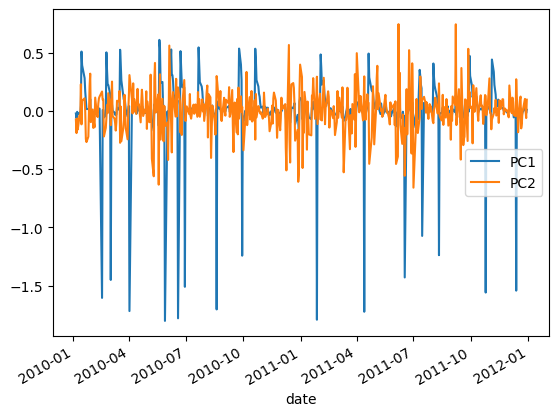

In [4]:
# PCA iteration
pca = PCA(n_components=2)
pcs = pca.fit_transform(rets_train)
pca_fit = pca.fit(rets_train)

pcs_df = pd.DataFrame(
    pcs,
    index=rets_train.index,
    columns=['PC1', 'PC2']
)

pcs_df.plot()

print(f"explained variances (in %): {pca_fit.explained_variance_ratio_*100}")

In [5]:
pca_full = PCA(n_components=99)
pca_full_fit = pca_full.fit(rets_train)
pcs_full = pca_full.fit_transform(rets_train)
pca_full_df = pd.DataFrame(pcs_full,
                           index = rets_train.index,
                           columns=[f"PCA{i}" for i in range(1,np.shape(pcs_full)[1]+1)])
pca_full_df.head()

X = np.cumsum(pca_full_fit.explained_variance_ratio_)

first 1 components explain 55.82% of the in-sample variation
first 2 components explain 76.21% of the in-sample variation
first 3 components explain 80.76% of the in-sample variation
first 4 components explain 84.74% of the in-sample variation
first 5 components explain 87.48% of the in-sample variation
first 6 components explain 88.5% of the in-sample variation
first 7 components explain 89.25% of the in-sample variation
first 8 components explain 89.95% of the in-sample variation
first 9 components explain 90.57% of the in-sample variation
first 10 components explain 91.14% of the in-sample variation


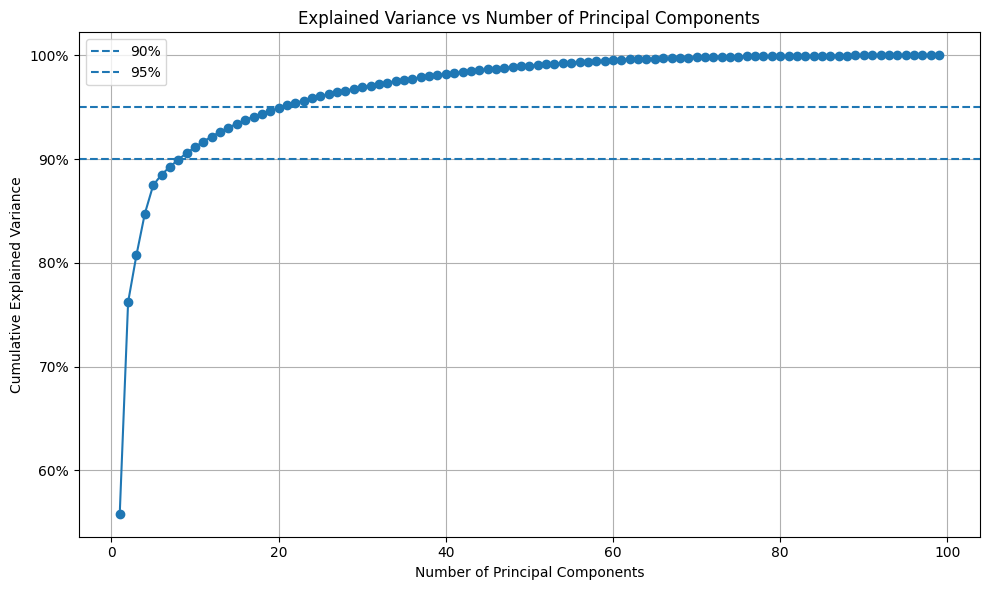

In [6]:
# PCs variations
# the first 4 components explain about 85% of the in-sample variation -> compare predictive performance of 1-5 PCs on the validation set?
for i in range(1,11):
    print(f"first {i} components explain {np.round(X[i-1]*100, 2)}% of the in-sample variation")


n_components = np.arange(1, len(X) + 1)

plt.figure(figsize=(10, 6))

plt.plot(n_components, X, marker='o')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Number of Principal Components')

# Optional: percentage formatting
plt.gca().yaxis.set_major_formatter(lambda x, _: f'{x*100:.0f}%')

# Optional: horizontal threshold lines
plt.axhline(y=0.9, linestyle='--', label='90%')
plt.axhline(y=0.95, linestyle='--', label='95%')

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

<Axes: xlabel='date'>

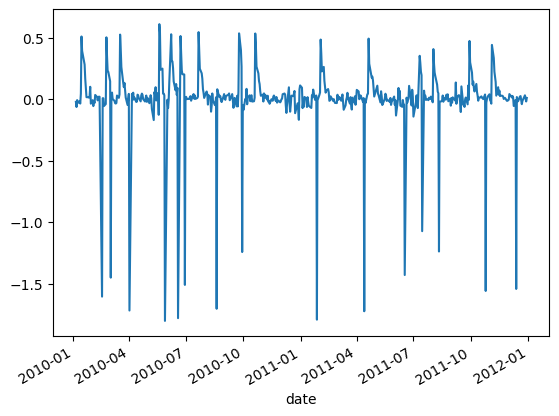

In [7]:
# 2-factor model because of noisy data
# time series methods for each factor
# Prediction of returns

pca_full_df["PCA1"].plot()

In [8]:
print(adfuller(pca_full_df["PCA1"]))

(np.float64(-11.408488309857109), np.float64(7.348901102453986e-21), 4, 498, {'1%': np.float64(-3.4435494520411605), '5%': np.float64(-2.8673612117611267), '10%': np.float64(-2.5698704830567247)}, np.float64(217.55018504110149))


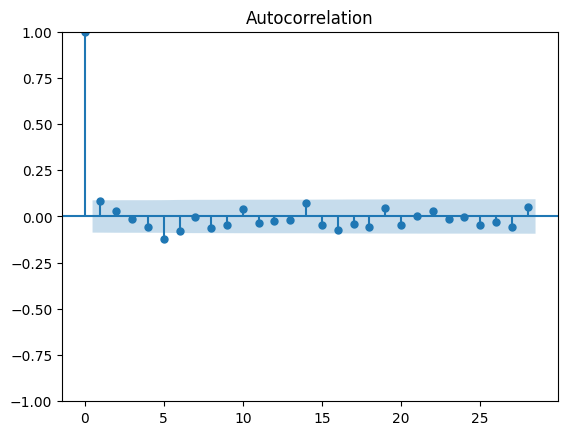

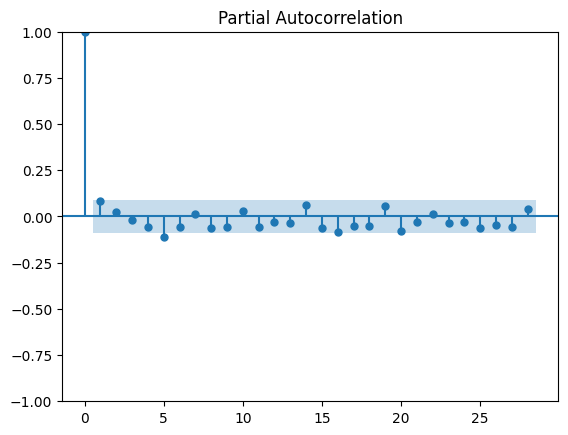

In [9]:
plot_acf(pca_full_df["PCA1"]);
plot_pacf(pca_full_df["PCA1"]);

In [14]:
model = AutoReg(pca_full_df["PCA1"],
                lags = [1, 5],
                trend = "n",
                )
res = model.fit()

c:\Main drive\University studies\LSE\ST458 Financial Statistics II\Project\st458_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [15]:
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:                   PCA1   No. Observations:                  503
Model:              Restr. AutoReg(5)   Log Likelihood                -102.273
Method:               Conditional MLE   S.D. of innovations              0.297
Date:                Sun, 29 Mar 2026   AIC                            210.547
Time:                        12:24:19   BIC                            223.179
Sample:                             5   HQIC                           215.504
                                  503                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PCA1.L1        0.0762      0.044      1.715      0.086      -0.011       0.163
PCA1.L5       -0.1162      0.044     -2.614      0.009      -0.203      -0.029
                                    Roots           

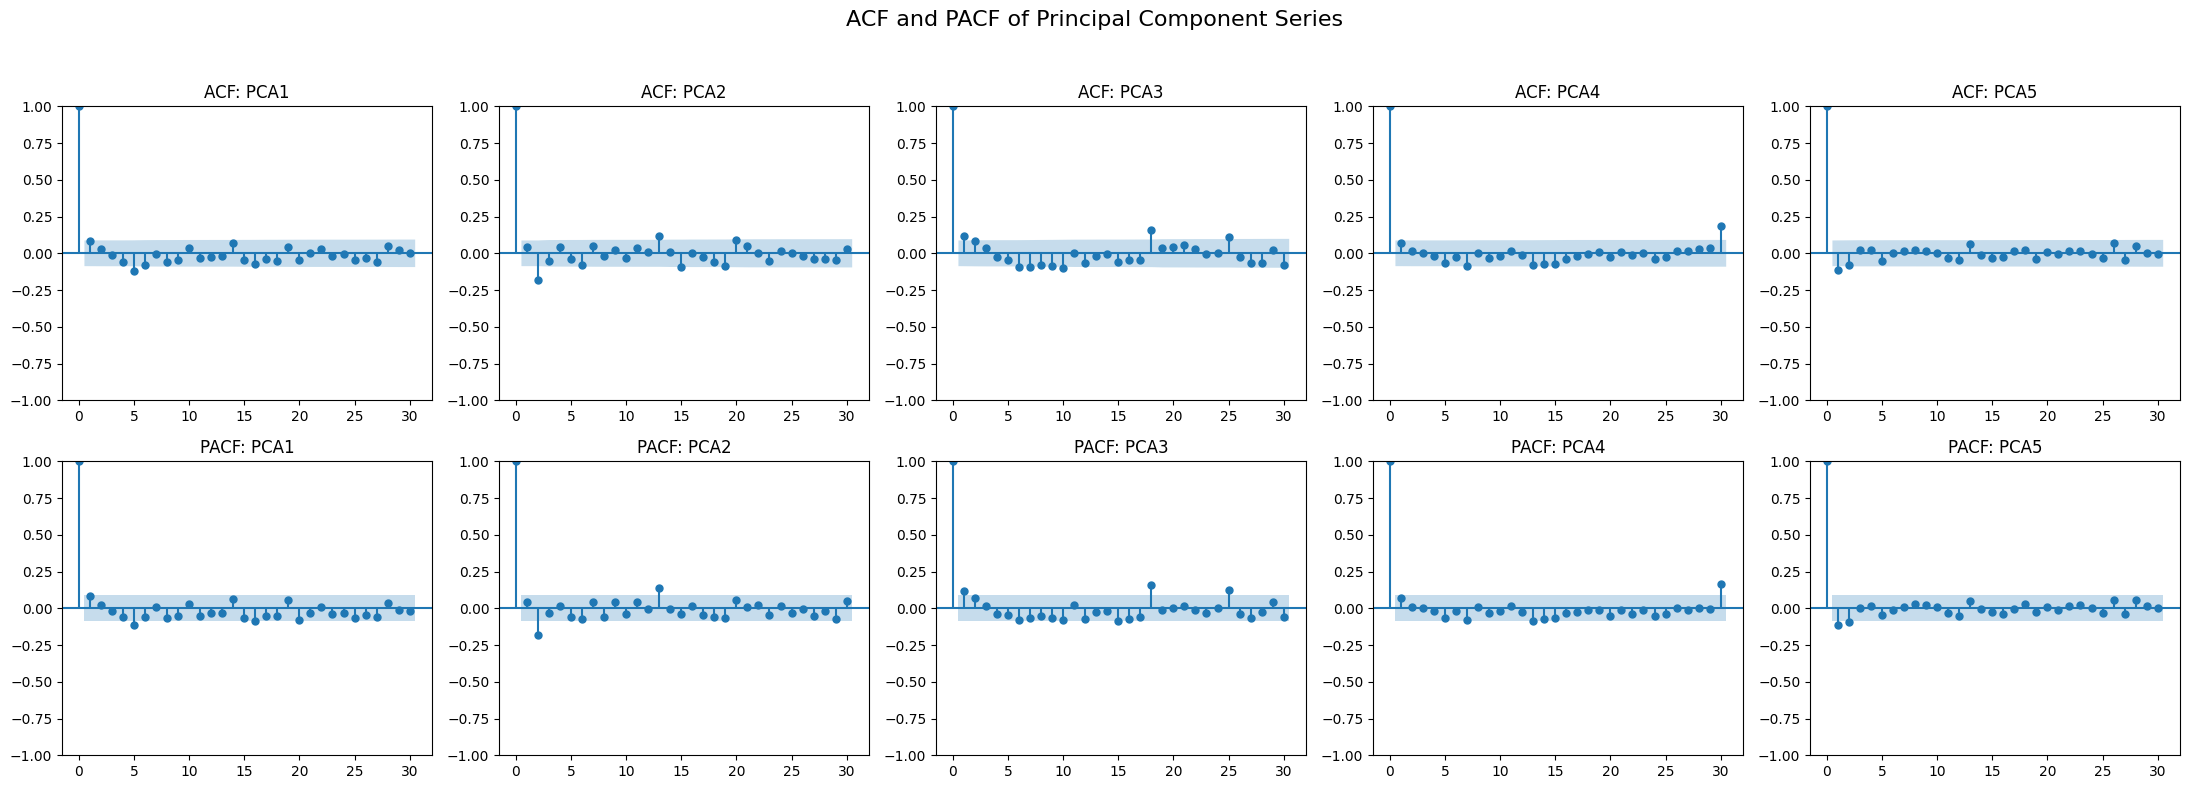

In [30]:
pcs = pca_full_df[["PCA1", "PCA2", "PCA3", "PCA4", "PCA5"]]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle("ACF and PACF of Principal Component Series", fontsize=16)

for i, col in enumerate(pcs.columns):
    series = pcs[col].dropna()

    plot_acf(series, ax=axes[0, i], lags=30)
    axes[0, i].set_title(f"ACF: {col}")

    plot_pacf(series, ax=axes[1, i], lags=30, method="ywm")
    axes[1, i].set_title(f"PACF: {col}")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Candidate AR models:
- PC1: lag 1 and 5
- PC2: lag 2
- PC3: lag 1
- PC4: None (long-memory -> monthly?)
- PC5: None (no significant lags)

Note: AutoReg is estimated using OLS -> inference may be a bit unreliable because we can't necessarily assume normality

c:\Main drive\University studies\LSE\ST458 Financial Statistics II\Project\st458_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                            AutoReg Model Results                             
Dep. Variable:                   PCA1   No. Observations:                  503
Model:              Restr. AutoReg(5)   Log Likelihood                -102.273
Method:               Conditional MLE   S.D. of innovations              0.297
Date:                Sun, 29 Mar 2026   AIC                            210.547
Time:                        13:22:09   BIC                            223.179
Sample:                             5   HQIC                           215.504
                                  503                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PCA1.L1        0.0762      0.044      1.715      0.086      -0.011       0.163
PCA1.L5       -0.1162      0.044     -2.614      0.009      -0.203      -0.029
                                    Roots           

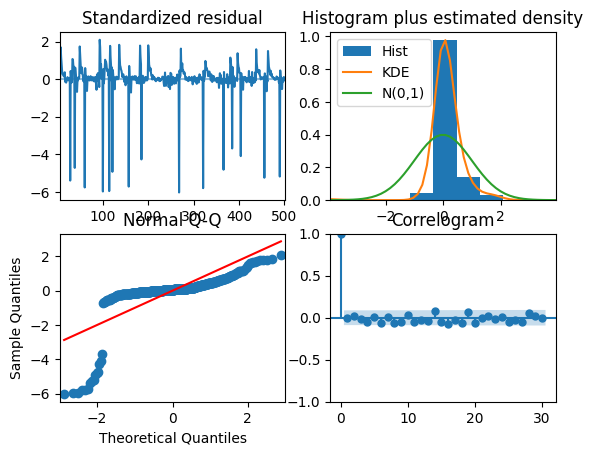

In [43]:
model_pc1 = AutoReg(pca_full_df["PCA1"],
                lags = [1,5],
                trend = "n",
                )
res_pc1 = model_pc1.fit()
print(res_pc1.summary())
res_pc1.plot_diagnostics(lags = 30);
print(acorr_ljungbox(res_pc1.resid))
# the first component is very jumpy but the jumps seem to follow a pattern

c:\Main drive\University studies\LSE\ST458 Financial Statistics II\Project\st458_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                            AutoReg Model Results                             
Dep. Variable:                   PCA2   No. Observations:                  503
Model:              Restr. AutoReg(2)   Log Likelihood                 154.693
Method:               Conditional MLE   S.D. of innovations              0.178
Date:                Sun, 29 Mar 2026   AIC                           -305.387
Time:                        13:22:18   BIC                           -296.953
Sample:                             2   HQIC                          -302.078
                                  503                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PCA2.L2       -0.1810      0.044     -4.122      0.000      -0.267      -0.095
                                    Roots                                    
                  Real          Imaginary           M

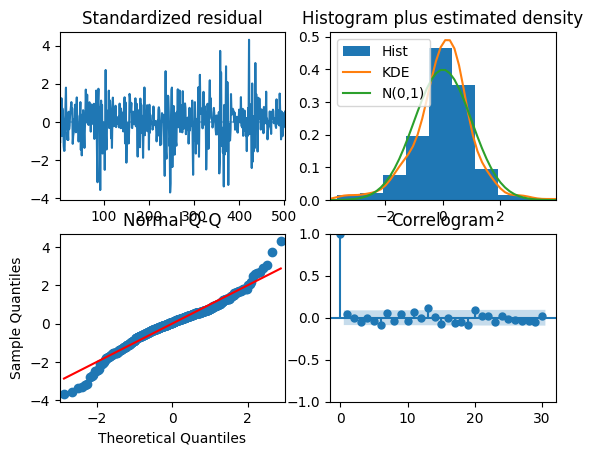

In [44]:
model_pc2 = AutoReg(pca_full_df["PCA2"],
                lags = [2],
                trend = "n",
                )
res_pc2 = model.fit()
print(res_pc2.summary())
res_pc2.plot_diagnostics(lags = 30);
print(acorr_ljungbox(res_pc2.resid))

c:\Main drive\University studies\LSE\ST458 Financial Statistics II\Project\st458_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                            AutoReg Model Results                             
Dep. Variable:                   PCA2   No. Observations:                  503
Model:              Restr. AutoReg(2)   Log Likelihood                 154.693
Method:               Conditional MLE   S.D. of innovations              0.178
Date:                Sun, 29 Mar 2026   AIC                           -305.387
Time:                        13:22:24   BIC                           -296.953
Sample:                             2   HQIC                          -302.078
                                  503                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PCA2.L2       -0.1810      0.044     -4.122      0.000      -0.267      -0.095
                                    Roots                                    
                  Real          Imaginary           M

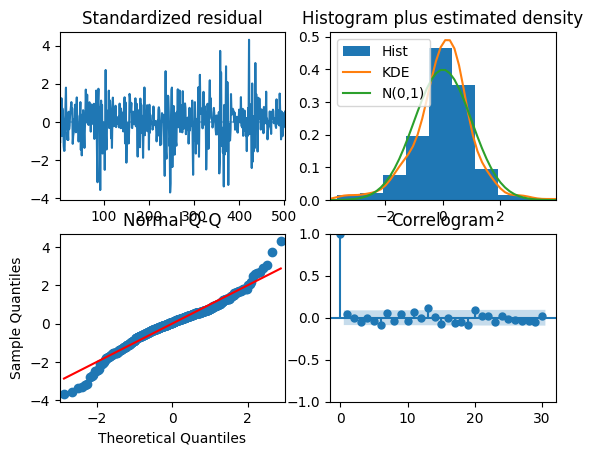

In [45]:
model_pc3 = AutoReg(pca_full_df["PCA3"],
                lags = [1],
                trend = "n",
                )
res_pc3 = model.fit()
print(res_pc3.summary())
res_pc3.plot_diagnostics(lags = 30);
print(acorr_ljungbox(res_pc3.resid))

c:\Main drive\University studies\LSE\ST458 Financial Statistics II\Project\st458_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                            AutoReg Model Results                             
Dep. Variable:                   PCA4   No. Observations:                  503
Model:             Restr. AutoReg(30)   Log Likelihood                 540.644
Method:               Conditional MLE   S.D. of innovations              0.077
Date:                Sun, 29 Mar 2026   AIC                          -1077.289
Time:                        13:23:18   BIC                          -1068.970
Sample:                            30   HQIC                         -1074.017
                                  503                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PCA4.L30       0.1886      0.044      4.324      0.000       0.103       0.274
                                    Roots                                     
                   Real          Imaginary          

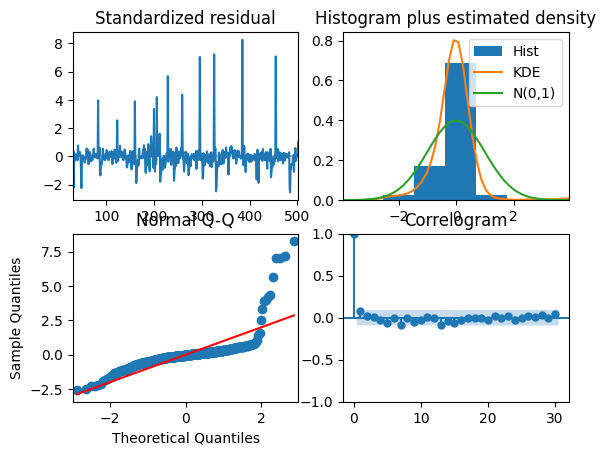

In [48]:
model_pc4 = AutoReg(pca_full_df["PCA4"],
                lags = [30],
                trend = "n",
                )
res_pc4 = model_pc4.fit()
print(res_pc4.summary())
res_pc4.plot_diagnostics(lags = 30);
print(acorr_ljungbox(res_pc4.resid))

#### Observations:
- Non-standard residuals (non-normal) -> how to account for this when constructing the actual portfolio (risk of fat-tailed negative events) -> we can't buy options with explosive returns on negative shocks, so I'm not sure
- Ljung-Box Q tests of serial independence pass on all the residuals

#### Strategy:
- Estimate the models (with an expanding window of k-days (determine k and look at parameter stability))
- Generate forecasts of expected values for principal components PCk_t+1 (for each OOS day)
- Estimate the correlations (factor loadings) for each of the 100 symbols (also determine rolling window and look at parameter stability over time)
- Given the expected returns (determined by estimated factor loadings + expected values for the PCs), we can update positions based on the Kelly Criterion in each period -> Cross-validate the performance of different factors used as covariates

In [ ]:
pcs.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 503 entries, 2010-01-05 to 2011-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PCA1    503 non-null    float64
 1   PCA2    503 non-null    float64
 2   PCA3    503 non-null    float64
 3   PCA4    503 non-null    float64
 4   PCA5    503 non-null    float64
dtypes: float64(5)
memory usage: 23.6 KB


In [62]:
# X = factor realizations over time
pc_df = pca_full_df[["PCA1", "PCA2", "PCA3", "PCA4"]]
X = pc_df.values   # shape: (T, 4)

beta_rows = []
intercepts = []
r2s = []

for symbol in rets_train.columns:
    y = rets_train[symbol].values

    model = LinearRegression(fit_intercept=True)
    model.fit(pc_df, y)

    y_hat = model.predict(pc_df)

    beta_rows.append(model.coef_)
    intercepts.append(model.intercept_)
    r2s.append(r2_score(y, y_hat))

beta_df = pd.DataFrame(
    beta_rows,
    index=rets_train.columns,
    columns=pc_df.columns
)

beta_df['Intercept'] = intercepts
beta_df['R2'] = r2s

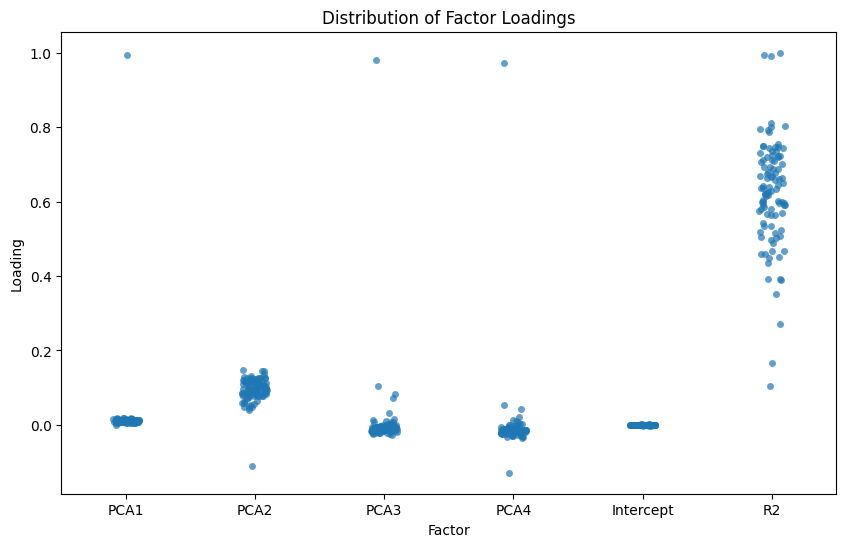

In [74]:
# Convert to long format
beta_long = beta_df.reset_index().melt(
    id_vars='symbol',
    var_name='Factor',
    value_name='Loading'
)

plt.figure(figsize=(10,6))
sns.stripplot(data=beta_long, x='Factor', y='Loading', jitter=True, alpha=0.7)
plt.title('Distribution of Factor Loadings')
plt.show()

In [84]:
beta_df["R2"].sort_values(ascending=False)
# There are different symbols (always 1) for each PC that is extremely positively correlated with the PC

symbol
LZK     0.999997
PQRS    0.992736
RYTX    0.991895
PWL     0.812228
HJC     0.804303
          ...   
HNTV    0.390243
SWRY    0.352175
XBRQ    0.271678
QVG     0.167419
DLT     0.103140
Name: R2, Length: 100, dtype: float64

## Portfolio Construction